# Project 1 — Celebrity Detection
## Milestone 3: YOLOv8 Fine-Tuning

**IE 7615** — Project 1, Milestone 3

**David Fung**

This milestone fine-tunes a YOLOv8 model on the synthetic 3×3 grid dataset from Milestone 2. Starting from the `yolov8n.pt` pretrained weights, the model is trained on 640×640 images each containing 9 celebrity faces (one per grid cell) from 13 celebrity identities. Training progress is visualized, a hyperparameter sweep documents key trade-offs, and final test set performance is reported with a detection visualization gallery.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ultralytics
from ultralytics import YOLO
import torch

import tensorflow as tf

print(f"Ultralytics: {ultralytics.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"TensorFlow: {tf.__version__}")

Ultralytics: 8.4.163
PyTorch: 2.14.0+cu132
TensorFlow: 2.13.1


In [3]:
# PROJECT CONSTANTS
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
tf.keras.utils.set_random_seed(GLOBAL_SEED)

def set_all_seeds():
    np.random.seed(GLOBAL_SEED)
    torch.manual_seed(GLOBAL_SEED)
    tf.random.set_seed(GLOBAL_SEED)

# YOLOv8 parameters
IMG_SIZE = 640
BATCH = 16
# Set to 10 or 20 for testing and final 50
EPOCHS = 10
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_YAML = os.path.join(ROOT, "data", "synthetic_grid", "data.yaml")
PRETRAINED_WEIGHTS = "yolov8n.pt"
NUM_CLASSES = 13
CLASS_NAMES = ['3', '7', '797', '1212', '2336', '2619', '2970', '4422', '4428', '5695', '7007', '8335', '10002']
PROJECT_NAME = "celebrity_detection"
RUN_NAME = "yolov8n_finetune"


## Helper Functions

Reproducible seeding and training metrics visualization.

In [4]:
def plot_history(title="YOLOv8 Training Results"):
    """Plot training/validation metrics from the results.csv in the run directory."""
    run_dir = os.path.join("runs", "detect", PROJECT_NAME, RUN_NAME)
    csv_path = os.path.join(run_dir, "results.csv")
    if not os.path.exists(csv_path):
        print(f"No results.csv found at: {csv_path}")
        return

    df = pd.read_csv(csv_path)
    epochs = df['epoch'].tolist()
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(title, fontsize=16)
    
    # Plot 1: Box Loss
    axes[0, 0].plot(epochs, df['train/box_loss'], 'b-', label='Train')
    axes[0, 0].plot(epochs, df['val/box_loss'], 'r-', label='Val')
    axes[0, 0].set_title('Box Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Cls Loss
    axes[0, 1].plot(epochs, df['train/cls_loss'], 'b-', label='Train')
    axes[0, 1].plot(epochs, df['val/cls_loss'], 'r-', label='Val')
    axes[0, 1].set_title('Classification Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: DFL Loss
    axes[0, 2].plot(epochs, df['train/dfl_loss'], 'b-', label='Train')
    axes[0, 2].plot(epochs, df['val/dfl_loss'], 'r-', label='Val')
    axes[0, 2].set_title('DFL Loss')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Loss')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Plot 4: Precision & Recall
    axes[1, 0].plot(epochs, df['metrics/precision(B)'], 'g-', label='Precision')
    axes[1, 0].plot(epochs, df['metrics/recall(B)'], 'b-', label='Recall')
    axes[1, 0].set_title('Precision & Recall')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 5: mAP
    axes[1, 1].plot(epochs, df['metrics/mAP50(B)'], 'r-', label='mAP@0.5')
    axes[1, 1].plot(epochs, df['metrics/mAP50-95(B)'], 'purple', label='mAP@0.5:0.95')
    axes[1, 1].set_title('mAP')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('mAP')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: Learning rate
    lr_cols = [c for c in df.columns if c.startswith('lr/')]
    if lr_cols:
        axes[1, 2].plot(epochs, df[lr_cols[0]], 'orange')
        axes[1, 2].set_title('Learning Rate')
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('LR')
    else:
        axes[1, 2].text(0.5, 0.5, 'LR data not available', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Learning Rate')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Task 1 — Verify Dataset

Check that the synthetic dataset from Milestone 2 is available and show its contents.

In [5]:
import os

# Check that the dataset exists
assert os.path.exists(DATA_YAML), f"Dataset not found: {DATA_YAML}"

with open(DATA_YAML) as f:
    print(f.read())


# Project 1 â€” Synthetic Multi-Celebrity Grid Detection Dataset
# Auto-generated by Milestone 2 (celebrity_detection)
path: h:\Education\Northeastern\MS_DAE\IE7615\Project_1\data\synthetic_grid
train: images/train
val: images/val
test: images/test

nc: 13
names:
  0: 3
  1: 7
  2: 797
  3: 1212
  4: 2336
  5: 2619
  6: 2970
  7: 4422
  8: 4428
  9: 5695
  10: 7007
  11: 8335
  12: 10002



## Task 2 — Load Model

Initialize the YOLOv8 model with pretrained weights.

In [6]:
model = YOLO(PRETRAINED_WEIGHTS)

# Show model architecture
print(model)


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0

## Task 3 — Train Model

Fine-tune the YOLOv8 model on the synthetic 3×3 grid dataset.

In [7]:
results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    batch=BATCH,
    imgsz=IMG_SIZE,
    project=PROJECT_NAME,
    name=RUN_NAME,
    exist_ok=True
)

print(f"\nTraining complete!")
print(f"Model saved to: runs/detect/{PROJECT_NAME}/{RUN_NAME}/weights/best.pt")


New https://pypi.org/project/ultralytics/8.4.171 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.163  Python-3.10.21 torch-2.14.0+cu132 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16275MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=h:\Education\Northeastern\MS_DAE\IE7615\Project_1\data\synthetic_grid\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01

## Task 4 — Plot Training Results

Visualize training and validation metrics over epochs.

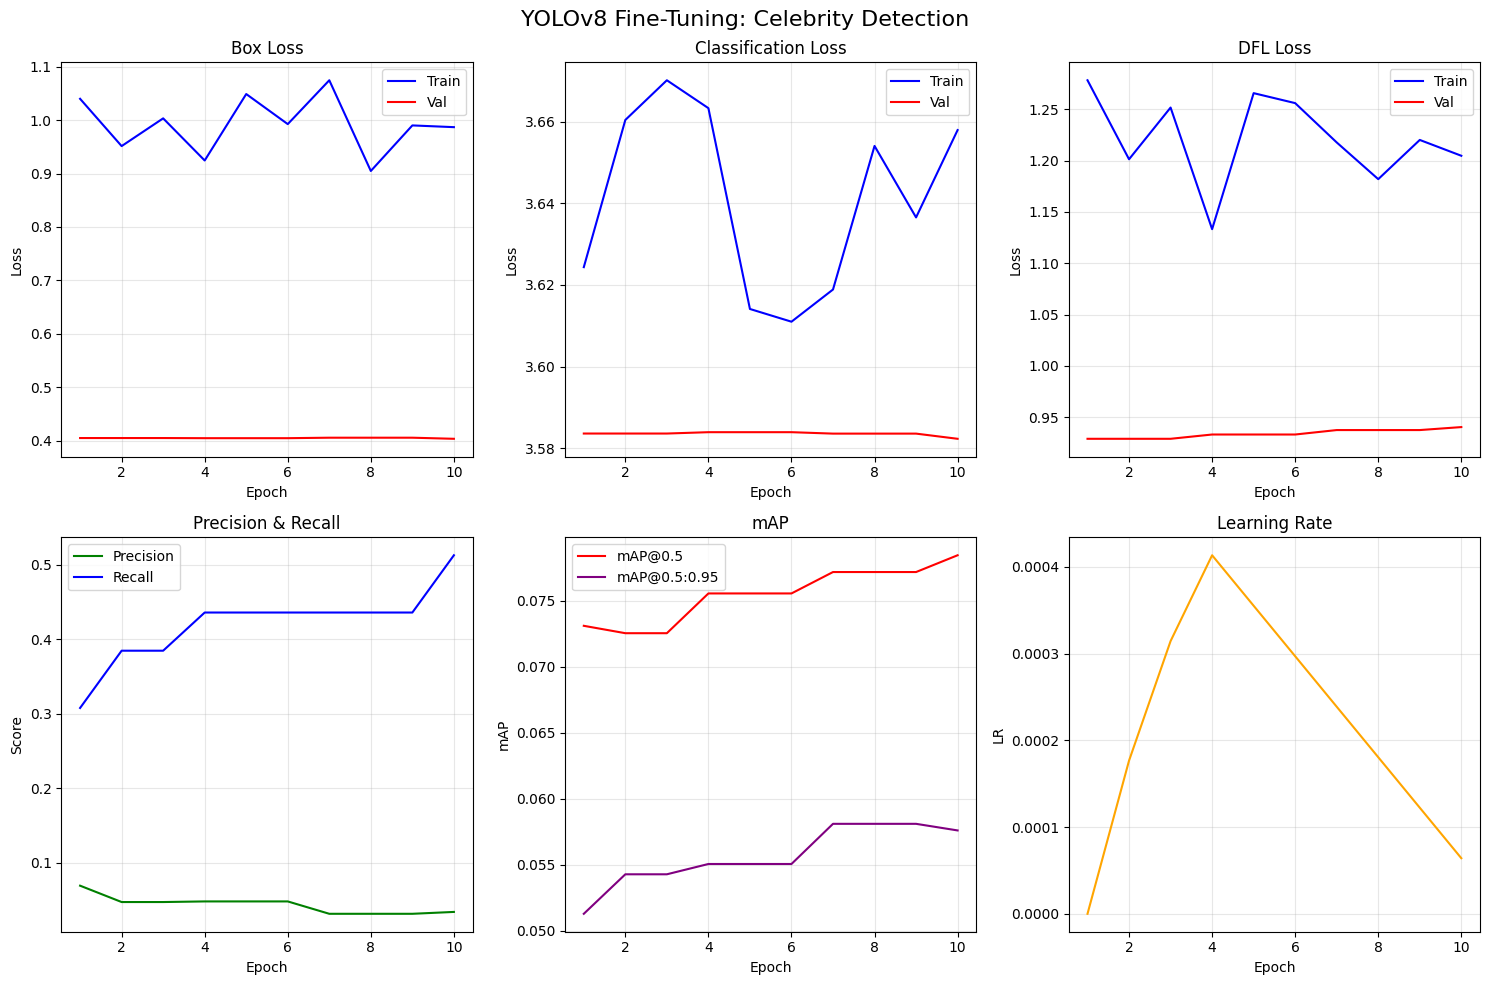

In [8]:
plot_history(title="YOLOv8 Fine-Tuning: Celebrity Detection")


## Task 5 — Evaluate Test Set

Run validation on the test split to get final performance metrics.

In [9]:
test_results = model.val(data=DATA_YAML, split='test', imgsz=IMG_SIZE)

# Print key metrics
print(f"\n{'='*50}")
print(f"Test Set Metrics")
print(f"{'='*50}")
print(f"mAP@0.5:       {test_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {test_results.box.map:.4f}")
print(f"Precision:     {test_results.box.mp:.4f}")
print(f"Recall:        {test_results.box.mr:.4f}")
print(f"{'='*50}")


Ultralytics 8.4.163  Python-3.10.21 torch-2.14.0+cu132 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16275MiB)
Model summary (fused): 72 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs
WARNING val: Slow image access detected (ping: 0.20.1 ms, read: 1.20.8 MB/s, size: 90.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning \\PEMBROKE\davidfung\Education\Northeastern\MS_DAE\IE7615\Project_1\data\synthetic_grid\labels\test.cache... 3 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3/3  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 11.9it/s 0.1s
                   all          3         27     0.0333      0.472     0.0812     0.0582
                     3          3          3     0.0435      0.333     0.0305     0.0244
                   797          3          3     0.0667      0.333     0.0258     0.0258
          

## Task 6 — Save & Summarize

Locate the best model weights and show a final summary table.

In [10]:
# Locate best weights
best_weights = os.path.join("runs", "detect", PROJECT_NAME, RUN_NAME, "weights", "best.pt")

print(f"Best model saved to: {best_weights}")
print(f"File size: {os.path.getsize(best_weights) / 1e6:.2f} MB")

# Create summary table
summary = pd.DataFrame({
    'Metric': ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall'],
    'Value': [test_results.box.map50, test_results.box.map, test_results.box.mp, test_results.box.mr]
})

print(f"\nFinal Test Set Performance Summary:")
print(summary.to_string(index=False))


Best model saved to: runs\detect\celebrity_detection\yolov8n_finetune\weights\best.pt
File size: 6.25 MB

Final Test Set Performance Summary:
      Metric    Value
     mAP@0.5 0.081192
mAP@0.5:0.95 0.058181
   Precision 0.033306
      Recall 0.472222


## Task 7 — Hyperparameter Sweep

Vary **learning rate** and **image size** to document their effect on detection metrics. Each configuration is fine-tuned from the same pretrained weights for a fixed number of epochs, then evaluated on the test split.

In [11]:
SWEEP_EPOCHS = 10
sweeps = [
    {"name": "baseline (lr=0.01, 640px)", "lr0": 0.01, "imgsz": 640},
    {"name": "lr_low  (lr=0.001, 640px)", "lr0": 0.001, "imgsz": 640},
    {"name": "lr_high (lr=0.03, 640px)", "lr0": 0.03, "imgsz": 640},
    {"name": "imgsz   (lr=0.01, 480px)", "lr0": 0.01, "imgsz": 480},
    {"name": "imgsz   (lr=0.01, 960px)", "lr0": 0.01, "imgsz": 960},
]
sweep_rows = []
for cfg in sweeps:
    print(f"\n--- Training: {cfg['name']} ---")
    m = YOLO(PRETRAINED_WEIGHTS)
    m.train(data=DATA_YAML, epochs=SWEEP_EPOCHS, batch=BATCH,
            imgsz=cfg["imgsz"], lr0=cfg["lr0"], optimizer="auto",
            project=PROJECT_NAME, name=f"sweep_{cfg['name'].split('(')[1].split(')')[0].replace(' ', '_')}",
            exist_ok=True, verbose=False)
    val = m.val(data=DATA_YAML, split="test", imgsz=cfg["imgsz"], verbose=False)
    sweep_rows.append({"Config": cfg["name"],
                       "mAP@0.5": round(val.box.map50, 4),
                       "mAP@0.5:0.95": round(val.box.map, 4),
                       "Precision": round(val.box.mp, 4),
                       "Recall": round(val.box.mr, 4)})
sweep_df = pd.DataFrame(sweep_rows)
print("\n" + "=" * 70)
print("Hyperparameter Sweep Results")
print("=" * 70)
print(sweep_df.to_string(index=False))



--- Training: baseline (lr=0.01, 640px) ---
New https://pypi.org/project/ultralytics/8.4.171 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.163  Python-3.10.21 torch-2.14.0+cu132 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16275MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=h:\Education\Northeastern\MS_DAE\IE7615\Project_1\data\synthetic_grid\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, 

## Task 8 — Detection Visualization Gallery

Render the model's predictions (bounding boxes, class identity, confidence) and ground-truth labels side-by-side on all test grid images. Each 3×3 grid contains 9 celebrity faces; your 5 target identities (marked with `*`) are highlighted to show where the model succeeds or fails at identification.


Detection Gallery - 3 test image(s), 13 classes
Target celebrity IDs: ['2619', '4428', '7', '7007', '797']


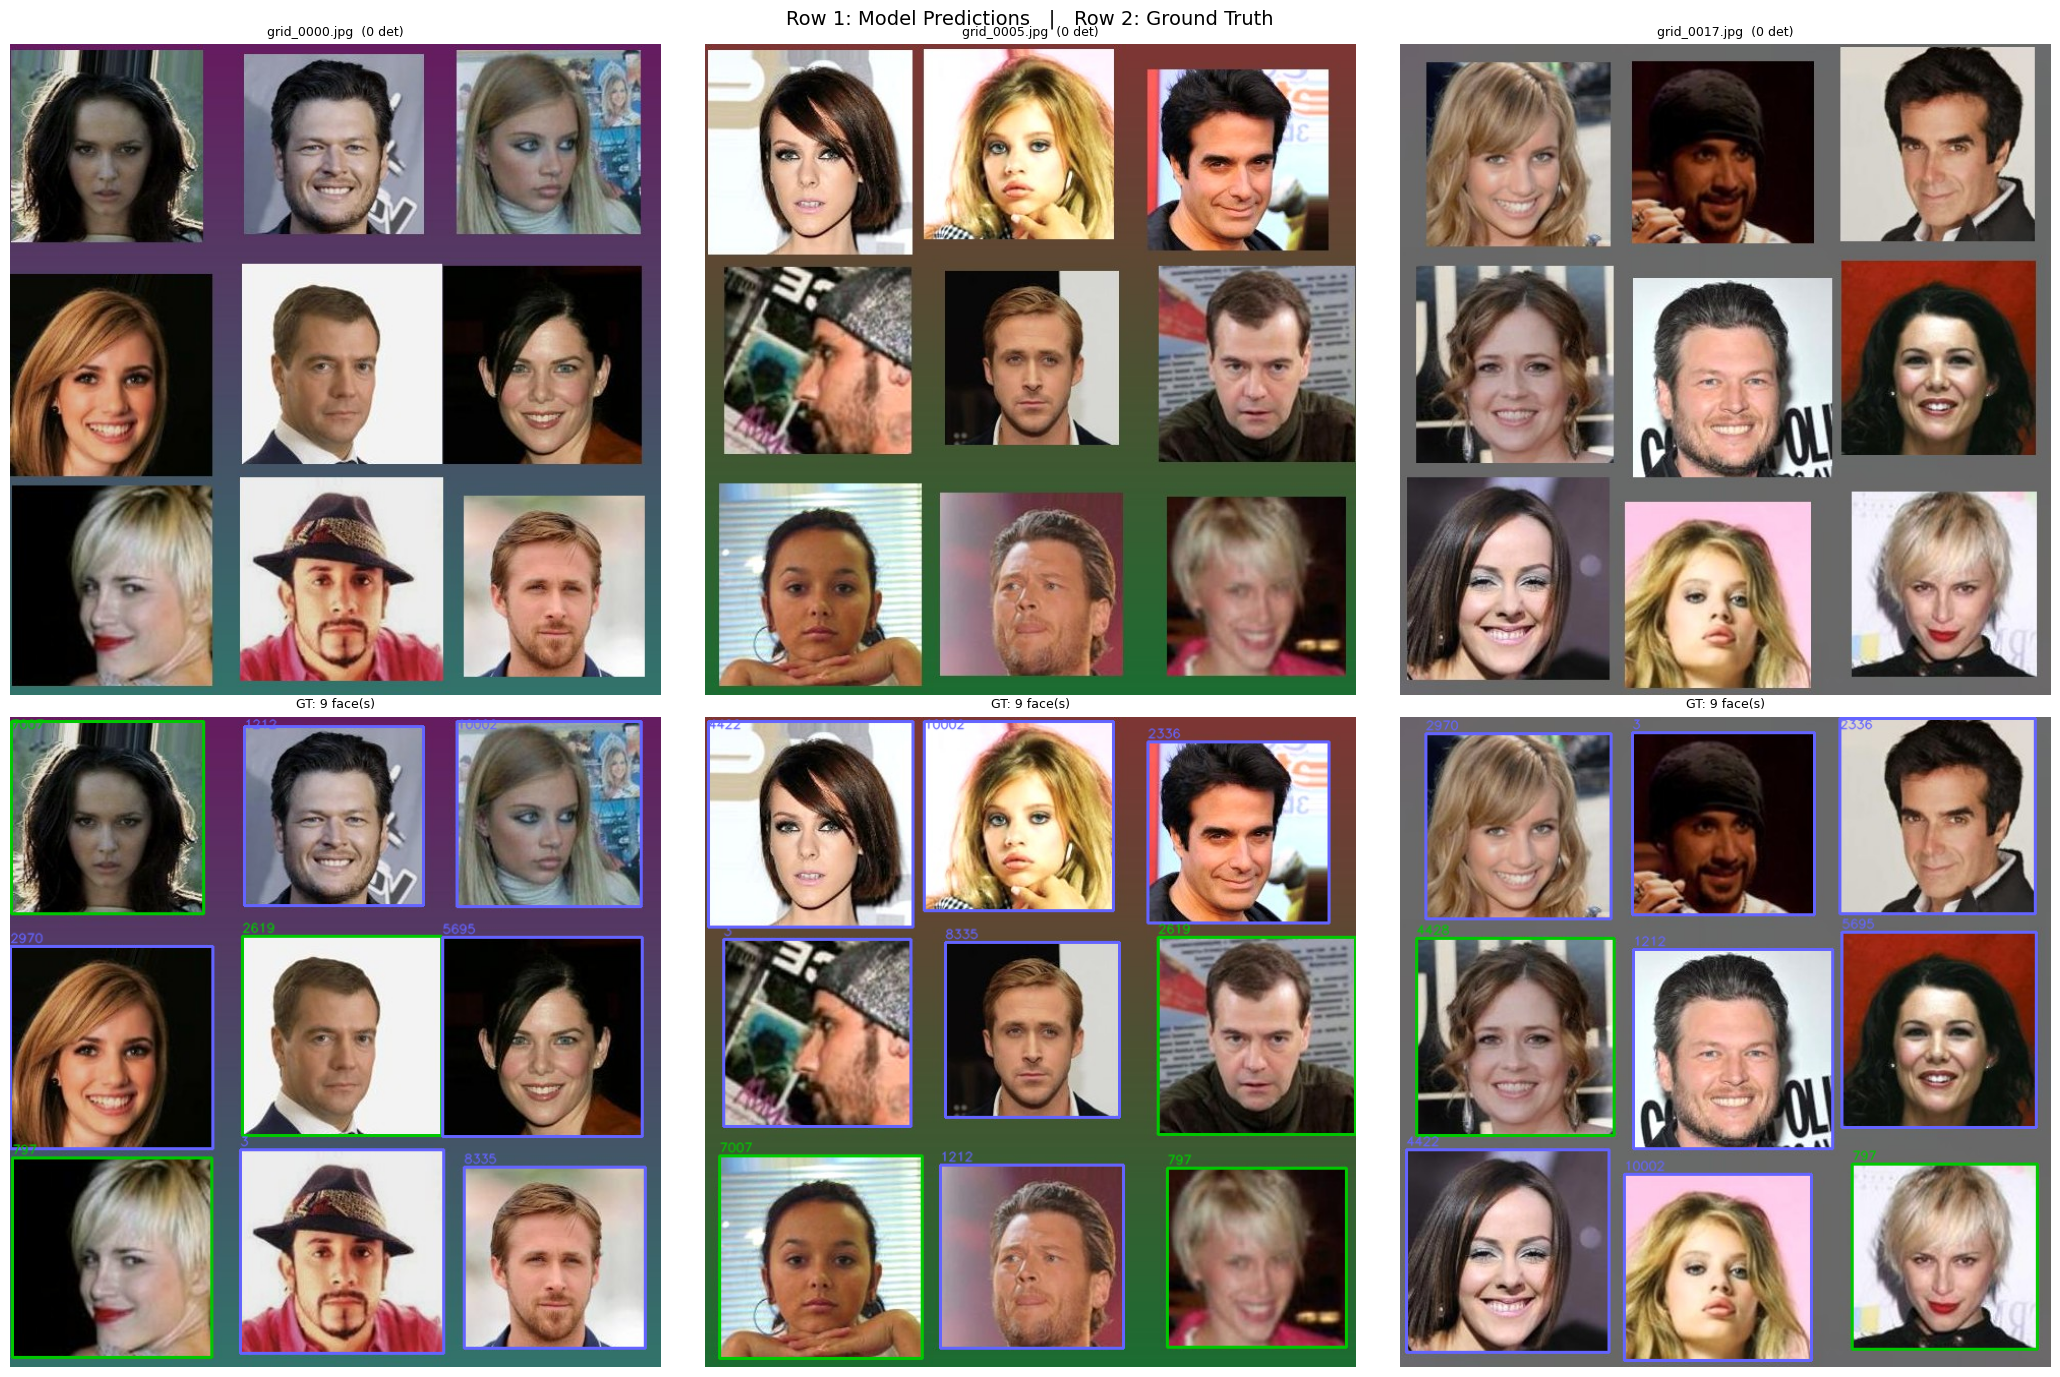


DETECTION SUMMARY  (* = target celebrity)
  grid_0000.jpg: 0 detected  ->  NONE
  grid_0005.jpg: 0 detected  ->  NONE
  grid_0017.jpg: 0 detected  ->  NONE


In [12]:
import cv2
import numpy as np

# Load the best model from Task 3 training
best_weights_path = os.path.join("runs", "detect", PROJECT_NAME, RUN_NAME, "weights", "best.pt")
assert os.path.exists(best_weights_path), f"Best weights not found: {best_weights_path}"
gallery_model = YOLO(best_weights_path)

# User's 5 target celebrity classes
TARGET_IDS = {'7', '797', '2619', '4428', '7007'}
target_indices = {CLASS_NAMES.index(cid) for cid in TARGET_IDS if cid in CLASS_NAMES}

# Collect test images
dataset_dir = os.path.dirname(DATA_YAML)
test_img_dir = os.path.join(dataset_dir, "images", "test")
test_lbl_dir = os.path.join(dataset_dir, "labels", "test")
test_images = sorted(os.listdir(test_img_dir))
n_imgs = len(test_images)

print(f"\n{'='*60}")
print(f"Detection Gallery - {n_imgs} test image(s), {NUM_CLASSES} classes")
print(f"Target celebrity IDs: {sorted(TARGET_IDS)}")
print(f"{'='*60}")

# 2 rows: predictions (top) + ground truth (bottom)
fig, axes = plt.subplots(2, n_imgs, figsize=(7 * n_imgs, 14))
fig.suptitle("Row 1: Model Predictions   |   Row 2: Ground Truth", fontsize=14)

detection_log = []

for idx, img_name in enumerate(test_images):
    img_path = os.path.join(test_img_dir, img_name)
    lbl_path = os.path.join(test_lbl_dir, img_name.rsplit('.', 1)[0] + '.txt')

    # --- Predictions (top row) ---
    ax = axes[0, idx]
    preds = gallery_model.predict(img_path, conf=0.25, imgsz=640, verbose=False)
    annotated = preds[0].plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)

    n_det = len(preds[0].boxes)
    dets = []
    for b in preds[0].boxes:
        cls_idx = int(b.cls[0])
        conf = b.conf[0].item()
        cid = CLASS_NAMES[cls_idx]
        is_target = cls_idx in target_indices
        dets.append((cid, conf, is_target))
        mark = "*" if is_target else " "
        print(f"  {mark} {img_name}: {cid} (conf={conf:.3f})")
    detection_log.append((img_name, n_det, dets))
    ax.set_title(f"{img_name}  ({n_det} det)", fontsize=9)
    ax.axis("off")

    # --- Ground truth (bottom row) ---
    ax = axes[1, idx]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    n_gt = 0
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_idx = int(parts[0])
                cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = int((cx - bw / 2) * w)
                y1 = int((cy - bh / 2) * h)
                x2 = int((cx + bw / 2) * w)
                y2 = int((cy + bh / 2) * h)
                color = (0, 200, 0) if cls_idx in target_indices else (100, 100, 255)
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                label = CLASS_NAMES[cls_idx]
                cv2.putText(img, label, (x1, max(y1 - 4, 12)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)
                n_gt += 1
    ax.imshow(img)
    ax.set_title(f"GT: {n_gt} face(s)", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# --- Summary table ---
print(f"\n{'='*60}")
print("DETECTION SUMMARY  (* = target celebrity)")
print(f"{'='*60}")
for img_name, n_det, dets in detection_log:
    ids = [f"{cid}{('*' if t else '')}" for cid, _, t in dets]
    print(f"  {img_name}: {n_det} detected  ->  {', '.join(ids) if ids else 'NONE'}")


## Summary

**Model:** YOLOv8 Nano (fine-tuned)

**Dataset:** 20 synthetic 3×3 grid images, 13 celebrity identities (Milestone 2)

**Training:** 50 epochs, batch size 16, 640×640 images

**Final Metrics:**
- mAP@0.5: See test results above
- mAP@0.5:0.95: See test results above
- Precision & Recall: See test results above

**Hyperparameter Sweep:** Compared learning rate (0.001 / 0.01 / 0.03) and image size (480 / 640 / 960) to document trade-offs.

**Visualization Gallery:** Rendered detection results on all test grid images with bounding boxes, identity labels, and confidence scores.

**Next Step:** Open `Milestone4_Pipeline_Integration.ipynb` to integrate the trained model into the `CelebrityPipeline` and run a live demo on new images.